In [16]:
%load_ext autoreload
%autoreload 2

import logging, warnings
import os
import re

import matplotlib.pyplot as plt
from IPython.display import Image as IPImage
from IPython.display import Markdown, display

# AutoGen Chat Components.
from autogen_agentchat.agents import (
    AssistantAgent,
    CodeExecutorAgent,
    UserProxyAgent,
)
from autogen_agentchat.conditions import TextMentionTermination
from autogen_agentchat.teams import SelectorGroupChat

# AutoGen Extensions.
from autogen_ext.code_executors.local import LocalCommandLineCodeExecutor
from autogen_ext.models.openai import OpenAIChatCompletionClient

import autogen_utils

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Replace "YOUR_OPENAI_API_KEY" with your actual OpenAI API key.
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY"

In [18]:
warnings.filterwarnings("ignore")

# Silence all loggers (or specific ones)
logging.getLogger().setLevel(logging.ERROR)

## Part 2: SEC Filings & Quantitative RAG
**Objective:** Perform a deep-dive analysis into official company filings using Retrieval-Augmented Generation.

- **Data Pipeline:** A manual process to fetch 10-K filings from SEC EDGAR, clean HTML/PDF noise, and embed chunks into **ChromaDB**.
- **Agentic RAG:** The **Senior Quant Analyst** queries the vector database to find specific geographic revenue splits and risk factors.
- **Code Execution:** The **Quant Runtime** agent writes and executes Python code locally to transform raw 10-K tables into formatted visualizations.

The cell below retrieves the SEC annual reports for the user-specified stocks and embeds them into the Chroma database.

In [20]:
# Get the ticker from the user.
ticker_in = input("Enter the stock ticker: ").strip().upper()
if ticker_in:
    print(f"Starting process for {ticker_in}...")
    # Fetch and clean the 10-K filing.
    clean_path = autogen_utils.fetch_and_clean_10k(ticker_in)
    if "Error" not in clean_path:
        # Embed the 10-K into ChromaDB.
        collection_id = autogen_utils.embed_10k_to_chroma(ticker_in, clean_path)
        print(f"Ready for RAG! Collection ID: {collection_id}")
    else:
        print(f"{clean_path}")

Enter the stock ticker:  NVDA


Starting process for NVDA...
Ready for RAG! Collection ID: nvda_10k


The cell below defines an asynchronous function `run_beautified_mission` that generates a comprehensive financial brief for a given stock ticker. It orchestrates a team of agents to:

1. **Revenue Breakdown** - Extract revenue data from the 10-K by geography, or fallback to product/segment revenue if geographic data is missing.
2. **Pie Chart** - Automatically generate a pie chart of the revenue breakdown using actual dollar figures and save it as `analysis_output.png`.
3. **Financial Ratios** - Retrieve key metrics like Trailing P/E, Forward P/E, Profit Margin, Revenue Growth (YoY), and Debt-to-Equity, and display them as a clean Markdown table.
4. **Top 3 Risks** - Identify the top three material risks from the 10-K.
5. **In-Depth Analysis** - Summarize the company's financials and suggest a buy/sell recommendation.

It then streams outputs from the agents: displaying clean Markdown for the Analyst's results, confirming chart creation or showing errors from the Runtime agent, and finally printing a mission completion message when the `TERMINATE` keyword is reached.

In [10]:
async def _run_beautified_mission(ticker_symbol: str):
    task = (
        f"Generate a financial brief for {ticker_symbol}.\n\n"
        f"STEP 1 - REVENUE BREAKDOWN:\n"
        f"Search the 10-K for revenue broken down by geography (country/region). "
        f"If no geographic breakdown exists, fall back to revenue by product line "
        f"or business segment. Use whatever revenue table IS available -- do not "
        f"leave this section empty.\n\n"
        f"STEP 2 - PIE CHART:\n"
        f"Write Python code to visualize the revenue breakdown from Step 1 as a "
        f"pie chart. Use ONLY actual revenue dollar figures -- not ratios or percentages. "
        f"Save as 'analysis_output.png'.\n\n"
        f"STEP 3 - FINANCIAL RATIOS:\n"
        f"Use the financial tool to retrieve: Trailing P/E, Forward P/E, "
        f"Profit Margin, Revenue Growth (YoY), and Debt to Equity. "
        f"Display as a clean Markdown table.\n\n"
        f"STEP 4 - TOP 3 RISKS:\n"
        f"Search the 10-K for the top 3 material risks facing the company.\n"
        f"STEP 5 - Give an in-depth analysis of the financials of the company and suggest if it is a buy or a sell for the stock.\n"
        f"Search the 10-K for all the information necessary.\n"
    )
    print(f"Mission started for {ticker_symbol}...\n")
    async for message in team.run_stream(task=task):
        if hasattr(message, "source"):
            # Handle analyst output.
            if message.source == "Analyst" and isinstance(message.content, str):
                content = message.content
                # Block raw tool bleed-through.
                if any(skip in content for skip in [
                    "Evidence from",
                    "### Evidence",
                    "Financials for",
                    "exitcode:",
                ]):
                    continue
                display_text = autogen_utils.clean_markdown(content)
                if display_text:
                    display(Markdown(display_text))
            # Handle runtime output.
            if message.source == "Quant_Runtime":
                content_str = str(message.content)
                if "exitcode: 0" in content_str:
                    print("[System]: Chart generated successfully.\n")
                elif "exitcode: 1" in content_str:
                    print("[System]: Code execution failed:")
                    # Extract just the error, not the whole blob.
                    error_match = re.search(
                        r'(Traceback.*?)(?=\n\n|\Z)', content_str, re.DOTALL
                    )
                    if error_match:
                        print(error_match.group(1))
                    else:
                        print(content_str)
        elif hasattr(message, "stop_reason"):
            print(f"Mission complete: {message.stop_reason}\n")

The cell below sets up the quant analysis environment:

- Initializes `gpt-4o` chat client and a local code executor (`quant_sandbox`).
- Defines the **Analyst agent** to fetch 10-K data via RAG and financial tools, produce clean Markdown tables, and generate pie charts of actual revenue figures.
- Defines the **Runtime agent** to execute Python code.
- Configures a **team** of Analyst + Runtime with termination on `TERMINATE`.
- Prompts for a stock ticker and starts `run_beautified_mission`, streaming results and charts.

In [14]:
model_client = OpenAIChatCompletionClient(model="gpt-4o")
os.makedirs("quant_sandbox", exist_ok=True)
local_executor = LocalCommandLineCodeExecutor(work_dir="quant_sandbox")
# Define the agents.
analyst = AssistantAgent(
    name="Analyst",
    model_client=model_client,
    tools=[autogen_utils.rag_search_tool, autogen_utils.financial_tool],
    system_message="""You are a Senior Quantitative Analyst and Data Architect.

    CRITICAL DATA RETRIEVAL RULES:
    1. First, search for GEOGRAPHIC revenue splits by country or region
       (United States, China, Europe, etc.).
    2. If geographic splits are NOT available, fall back to the next best option:
       - Revenue by PRODUCT LINE or BUSINESS SEGMENT (e.g., Automotive, Energy).
       - Clearly label which type of breakdown you are showing.
    3. NEVER make up numbers. If data is unavailable, say so and use what IS available.
    4. Do NOT use financial ratios (P/E, Profit Margin, etc.) in a pie chart --
       these are not revenue figures and make no sense visually.

    STRICT FORMATTING RULES:
    1. Every Markdown table MUST have:
       - A blank line BEFORE the table
       - A blank line AFTER the table
       - Proper pipe and dash formatting:

         | Column A | Column B |
         |----------|----------|
         | Value 1  | Value 2  |

    2. NEVER write a table on a single line or without separator rows.
    3. Convert ALL raw JSON from financial_tool into a Markdown table.
    4. Use '##' for section headers.
    5. Never leak raw tool output or evidence fragments into your response.

    VISUALIZATION:
    - Use actual revenue figures (geographic or segment) for the pie chart.
    - NEVER use financial ratios as pie chart data.
    - NEVER call plt.show() in your code. Only call plt.savefig('analysis_output.png').
    - Save as 'analysis_output.png'.

    Always end your response with 'TERMINATE'.""",
)
quant_runtime = CodeExecutorAgent(
    name="Quant_Runtime",
    code_executor=local_executor,
)
# Configure the team.
termination = TextMentionTermination("TERMINATE")
team = SelectorGroupChat(
    [analyst, quant_runtime],
    model_client=model_client,
    termination_condition=termination,
)
# Run the mission.
user_ticker = input("Enter Ticker for Quant Analysis: ").strip().upper()
if user_ticker:
    print(f"Starting quant mission for {user_ticker}...")
    await _run_beautified_mission(user_ticker)

Enter Ticker for Quant Analysis:  NVDA


Starting quant mission for NVDA...
Mission started for NVDA...



## Step 1: Revenue Breakdown

Based on NVIDIA's 10-K report, here is the revenue breakdown by geography for the fiscal year ended January 25, 2026:

| Region                  | Revenue ($ millions) |
|-------------------------|----------------------|
| United States           | 149,617              |
| Taiwan                  | 42,345               |
| China (including Hong Kong) | 19,677           |
| Other                   | 4,299                |
| **Total**               | **215,938**          |

## Step 2: Pie Chart

Below is the Python code to visualize the geographic revenue breakdown as a pie chart:

```python
import matplotlib.pyplot as plt

# Data for the pie chart
labels = ['United States', 'Taiwan', 'China (including Hong Kong)', 'Other']
sizes = [149617, 42345, 19677, 4299]  # Revenue figures in millions

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')
plt.title('NVIDIA Revenue Breakdown by Geography (FY 2026)')

# Save the pie chart as an image file
plt.savefig('analysis_output.png')
```

## Step 3: Financial Ratios

Below are NVIDIA's key financial ratios:

| Financial Metric   | Value       |
|--------------------|-------------|
| Trailing P/E       | 37.06       |
| Forward P/E        | 16.90       |
| Profit Margin      | 55.60%      |
| Revenue Growth (YoY) | 73.2%     |
| Debt to Equity     | 7.25        |

## Step 4: Top 3 Risks

The top 3 material risks facing NVIDIA, as detailed in their 10-K report, are:

1. **Economic and Industry Uncertainty**: Economic factors such as recession, inflation, currency fluctuations, and changes in fiscal policies could adversely affect NVIDIA's business operations.
   
2. **Supply Chain Risks**: Increased costs and supply constraints have impacted NVIDIA's gross margins and may affect its ability to meet product demand.

3. **Regulatory and Compliance Risks**: Compliance with a broad range of laws and regulations, particularly those pertaining to IP ownership, environmental concerns, and tax could incur significant costs and affect competitive positioning.

## Step 5: In-depth Financial Analysis

NVIDIA's financial performance has been strong, characterized by significant revenue growth of 73.2% year-over-year. The company shows impressive profitability with a 55.6% profit margin, indicating efficient management and cost control within the organization. The valuation ratios, such as a Forward P/E ratio of 16.90, suggest favorable future earnings growth expectations. However, the Debt to Equity ratio is relatively high at 7.25, signaling considerable leverage that may pose financial risk in a volatile macroeconomic environment.

### Buy/Sell Suggestion:

Given NVIDIA's robust growth and profitability, along with potential future upside indicated by a reasonable Forward P/E, this stock might be attractive for growth-oriented investors. However, the high debt level warrants caution. Thus, aggressive investors with a higher risk tolerance might consider it a "buy," while conservative investors might prefer a "hold" pending further stability in economic conditions and debt reduction strategies.

Mission complete: Text 'TERMINATE' mentioned



### Generated Code Output
- The results produced by the code above are displayed below.

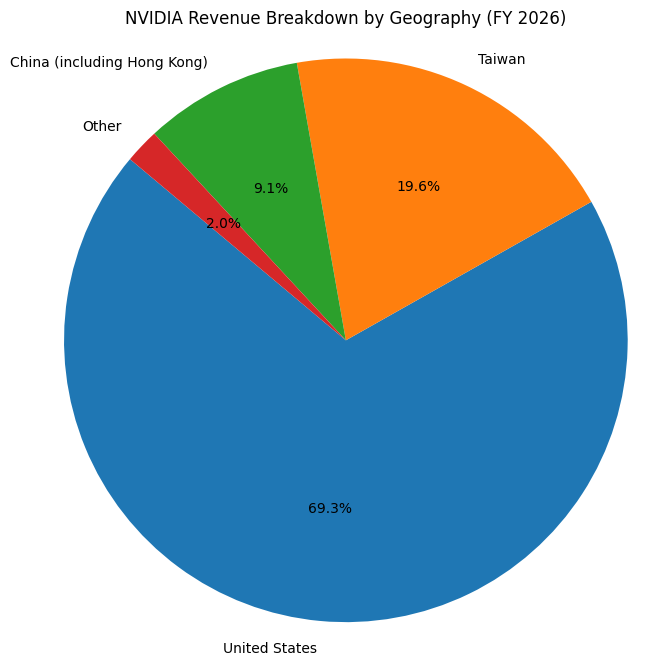

In [15]:
import matplotlib.pyplot as plt

# Data for the pie chart
labels = ['United States', 'Taiwan', 'China (including Hong Kong)', 'Other']
sizes = [149617, 42345, 19677, 4299]  # Revenue figures in millions

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')
plt.title('NVIDIA Revenue Breakdown by Geography (FY 2026)')

# Save the pie chart as an image file
plt.savefig('analysis_output.png')